# Import the libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree

import random
import warnings
warnings.filterwarnings('ignore')

# Create a classification dataset

In [2]:
X, y = make_classification(n_features=5, n_redundant=0, n_informative=5, n_clusters_per_class=1)

In [4]:
df = pd.DataFrame(X, columns=['col1', 'col2', 'col3', 'col4', 'col5'])
df['target'] = y
df.head()

,col1,col2,col3,col4,col5,target
0,0.831546,-0.505954,-1.391826,0.811428,-2.444941,1
1,-2.633109,1.374819,-1.512881,-0.621018,-0.573133,0
2,-1.524921,0.088356,0.004844,0.236485,0.463879,0
3,0.863089,-1.519007,-0.979572,-0.241362,-2.545259,1
4,-2.011895,-1.363847,-0.844013,-2.024081,-0.424696,1


In [5]:
df.shape

(100, 6)

# Loose demo on how Random Forests work internally 

## Function for row sampling

In [6]:
def sample_rows(df, percent):
    return df.sample(int(percent * df.shape[0]), replace=True)

## Function for column (feature) sampling

In [7]:
def sample_features(df, percent):
    features = random.sample(df.columns.tolist()[:-1], int(percent * (df.shape[1] - 1)))
    new_df = df[features]
    new_df['target'] = df['target']
    return new_df

## Function for row + columns (feature) sampling

In [8]:
def combined_sampling(df, row_percent, col_percent):
    new_df = sample_rows(df, row_percent)
    return sample_features(new_df, col_percent)

## Creating datasets

In [9]:
df1 = combined_sampling(df, 0.5, 0.5)
df2 = combined_sampling(df, 0.5, 0.5)
df3 = combined_sampling(df, 0.5, 0.5)

In [10]:
print(df1.columns)
print(df2.columns)
print(df3.columns)

Index(['col4', 'col1', 'target'], dtype='object')
Index(['col5', 'col1', 'target'], dtype='object')
Index(['col2', 'col4', 'target'], dtype='object')


In [11]:
print(df1.shape)
print(df2.shape)
print(df3.shape)

(50, 3)
(50, 3)
(50, 3)


## Train three DecisonTrees

In [12]:
clf1 = DecisionTreeClassifier()
clf2 = DecisionTreeClassifier()
clf3 = DecisionTreeClassifier()

In [13]:
clf1.fit(df1.iloc[:, 0:2], df1.iloc[:, -1])
clf2.fit(df2.iloc[:, 0:2], df2.iloc[:, -1])
clf3.fit(df3.iloc[:, 0:2], df3.iloc[:, -1])

DecisionTreeClassifier()

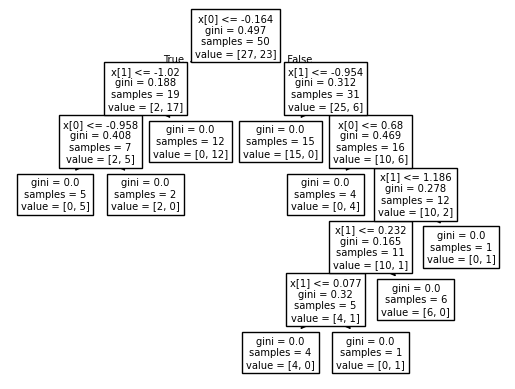

In [14]:
plot_tree(clf1);

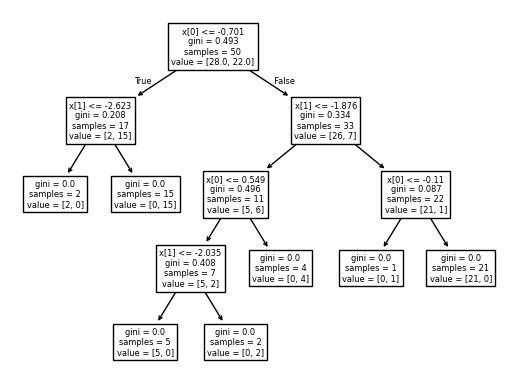

In [15]:
plot_tree(clf2);

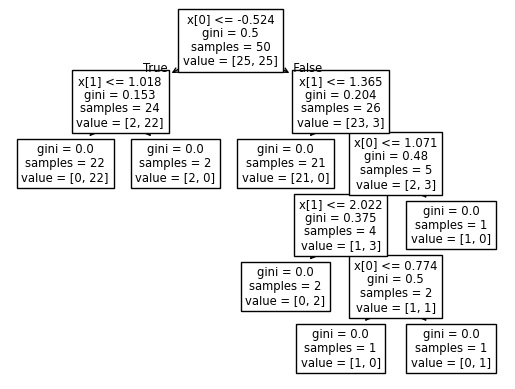

In [16]:
plot_tree(clf3);

In [17]:
print(clf1.predict(np.array([-1.042498,	-0.064323]).reshape(1,2)))
print(clf2.predict(np.array([-1.042498,	-0.064323]).reshape(1,2)))
print(clf3.predict(np.array([-1.042498,	-0.064323]).reshape(1,2)))

[1]
[1]
[1]
